# 01: Exploratory Data Analysis

**Project:** Predicting Retrofit Potential in UK Residential Buildings  
**Author:** Karan Homayounfar (25065219), UWE Bristol  
**Dataset:** UK EPC Open Data (MHCLG, 2024)  

This notebook explores the training sample (200,000 records, 2020-2024) before any modelling.  
It scores primarily on **C1 Exploration (15%)** and informs feature engineering decisions.

**Key questions:**
1. What is the class balance of the retrofit potential target?
2. What is the distribution of key numerical features?
3. Are there missing values, and how common are they?
4. Which features correlate with the target?
5. How does energy rating distribution vary by property type?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

TRAIN_SAMPLE = '../data/processed/epc_train_sample_200k.parquet'
TEST_SAMPLE  = '../data/processed/epc_test_sample_50k.parquet'
FIGURES_DIR  = '../report/figures'

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load data

In [2]:
df = pd.read_parquet(TRAIN_SAMPLE)
df_test = pd.read_parquet(TEST_SAMPLE)

print(f'Train sample shape: {df.shape}')
print(f'Test sample shape:  {df_test.shape}')
df.head(3)

Train sample shape: (200000, 41)
Test sample shape:  (50000, 41)


,UPRN,LODGEMENT_DATE,CURRENT_ENERGY_RATING,POTENTIAL_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,WALLS_DESCRIPTION,...,WALLS_ENERGY_EFF,ROOF_ENERGY_EFF,FLOOR_ENERGY_EFF,WINDOWS_ENERGY_EFF,MAINHEAT_ENERGY_EFF,HOT_WATER_ENERGY_EFF,LIGHTING_ENERGY_EFF,MAINHEATC_ENERGY_EFF,EFFICIENCY_GAP,RETROFIT_POTENTIAL
0,100091593582,2020-07-03,C,C,69,77.0,Flat,Mid-Terrace,England and Wales: 1900-1929,"Solid brick, as built, no insulation (assumed)",...,Poor,None,None,Average,Good,Good,Very Good,Average,8.0,0
1,10013026811,2021-02-10,C,B,70,88.0,House,Mid-Terrace,England and Wales: 1967-1975,"Cavity wall, filled cavity",...,Average,Good,None,Poor,Good,Good,Average,Good,18.0,0
2,100080955786,2024-12-02,C,B,69,85.0,House,Semi-Detached,England and Wales: 1950-1966,"Cavity wall, filled cavity",...,Average,Good,None,Good,Good,Good,Very Good,Good,16.0,0


In [3]:
print(df.dtypes.value_counts())
print(f'\nColumns: {list(df.columns)}')

object     21
float64    18
int64       1
int32       1
Name: count, dtype: int64

Columns: ['UPRN', 'LODGEMENT_DATE', 'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY', 'POTENTIAL_ENERGY_EFFICIENCY', 'PROPERTY_TYPE', 'BUILT_FORM', 'CONSTRUCTION_AGE_BAND', 'WALLS_DESCRIPTION', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'TENURE', 'TRANSACTION_TYPE', 'MAINS_GAS_FLAG', 'REGION', 'COUNTRY', 'CO2_EMISS_CURR_PER_FLOOR_AREA', 'CO2_EMISSIONS_CURRENT', 'CO2_EMISSIONS_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT', 'ENERGY_CONSUMPTION_POTENTIAL', 'HEATING_COST_CURRENT', 'HEATING_COST_POTENTIAL', 'HOT_WATER_COST_CURRENT', 'LIGHTING_COST_CURRENT', 'EXTENSION_COUNT', 'FIXED_LIGHTING_OUTLETS_COUNT', 'MULTI_GLAZE_PROPORTION', 'LOW_ENERGY_LIGHTING', 'NUMBER_HEATED_ROOMS', 'WALLS_ENERGY_EFF', 'ROOF_ENERGY_EFF', 'FLOOR_ENERGY_EFF', 'WINDOWS_ENERGY_EFF', 'MAINHEAT_ENERGY_EFF', 'HOT_WATER_ENERGY_EFF', 'LIGHTING_ENERGY_EFF', 'MAINHEATC_ENERGY_EFF', 'EFFICIENCY_GAP', 'RETROFIT_POT

## 2. Target variable: class balance

Train sample class balance:
RETROFIT_POTENTIAL
0    0.783
1    0.217
Name: proportion, dtype: float64

Test sample class balance:
RETROFIT_POTENTIAL
0    0.892
1    0.108
Name: proportion, dtype: float64


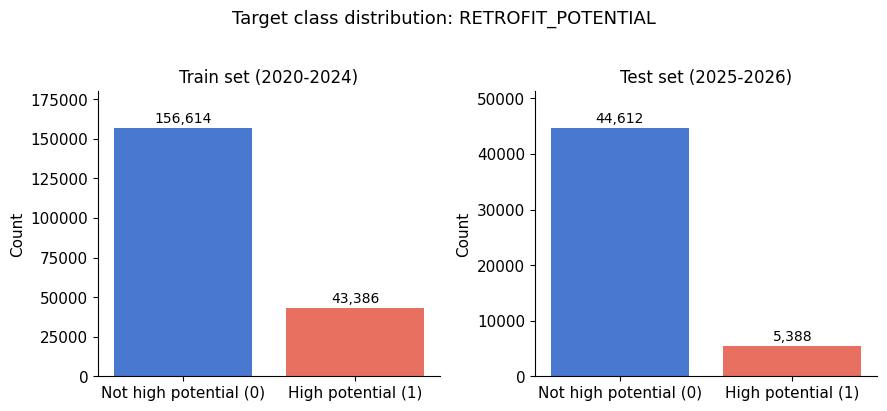

NOTE: Test set is more imbalanced (10.8% positive vs 21.7% in train).
This temporal distribution shift reflects higher energy standards in recent builds.


In [4]:
train_counts = df['RETROFIT_POTENTIAL'].value_counts()
test_counts  = df_test['RETROFIT_POTENTIAL'].value_counts()

print('Train sample class balance:')
print(df['RETROFIT_POTENTIAL'].value_counts(normalize=True).round(3))
print('\nTest sample class balance:')
print(df_test['RETROFIT_POTENTIAL'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
labels = ['Not high potential (0)', 'High potential (1)']

for ax, counts, title in zip(axes,
                             [train_counts, test_counts],
                             ['Train set (2020-2024)', 'Test set (2025-2026)']):
    bars = ax.bar(labels, counts.sort_index(), color=['steelblue', 'coral'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts) * 1.15)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(counts) * 0.01,
                f'{int(h):,}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Target class distribution: RETROFIT_POTENTIAL', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_class_balance.png', bbox_inches='tight')
plt.show()
print('NOTE: Test set is more imbalanced (10.8% positive vs 21.7% in train).')
print('This temporal distribution shift reflects higher energy standards in recent builds.')

**Finding:** The training set (certificates from 2020-2024) has approximately 21.7% positive labels, while the 2025-2026 test set has 10.8%. This temporal shift indicates that newer EPC certificates cover properties with less retrofit headroom, possibly because recent builds already comply with higher energy standards. A random train/test split would obscure this and inflate generalisation estimates.

## 3. Missing values

Columns with missing values: 13


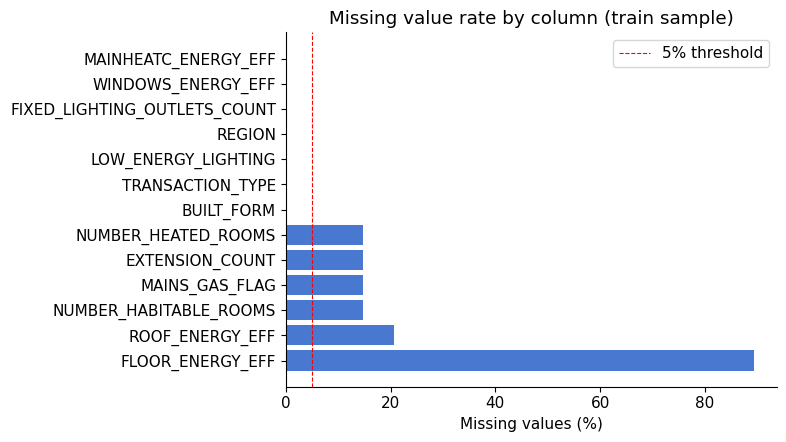


Top 10 columns by missing rate:
FLOOR_ENERGY_EFF          89.3%
ROOF_ENERGY_EFF           20.6%
NUMBER_HABITABLE_ROOMS    14.7%
MAINS_GAS_FLAG            14.7%
EXTENSION_COUNT           14.7%
NUMBER_HEATED_ROOMS       14.7%
BUILT_FORM                 0.1%
TRANSACTION_TYPE           0.1%
LOW_ENERGY_LIGHTING        0.0%
REGION                     0.0%
dtype: object


In [5]:
miss = df.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print(f'Columns with missing values: {len(miss_nonzero)}')

fig, ax = plt.subplots(figsize=(8, max(3, len(miss_nonzero) * 0.35)))
bars = ax.barh(miss_nonzero.index, miss_nonzero.values * 100, color='steelblue')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing value rate by column (train sample)')
ax.axvline(5, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_missing_values.png', bbox_inches='tight')
plt.show()

print('\nTop 10 columns by missing rate:')
print(miss_nonzero.head(10).apply(lambda x: f'{x:.1%}'))

## 4. Numerical feature distributions

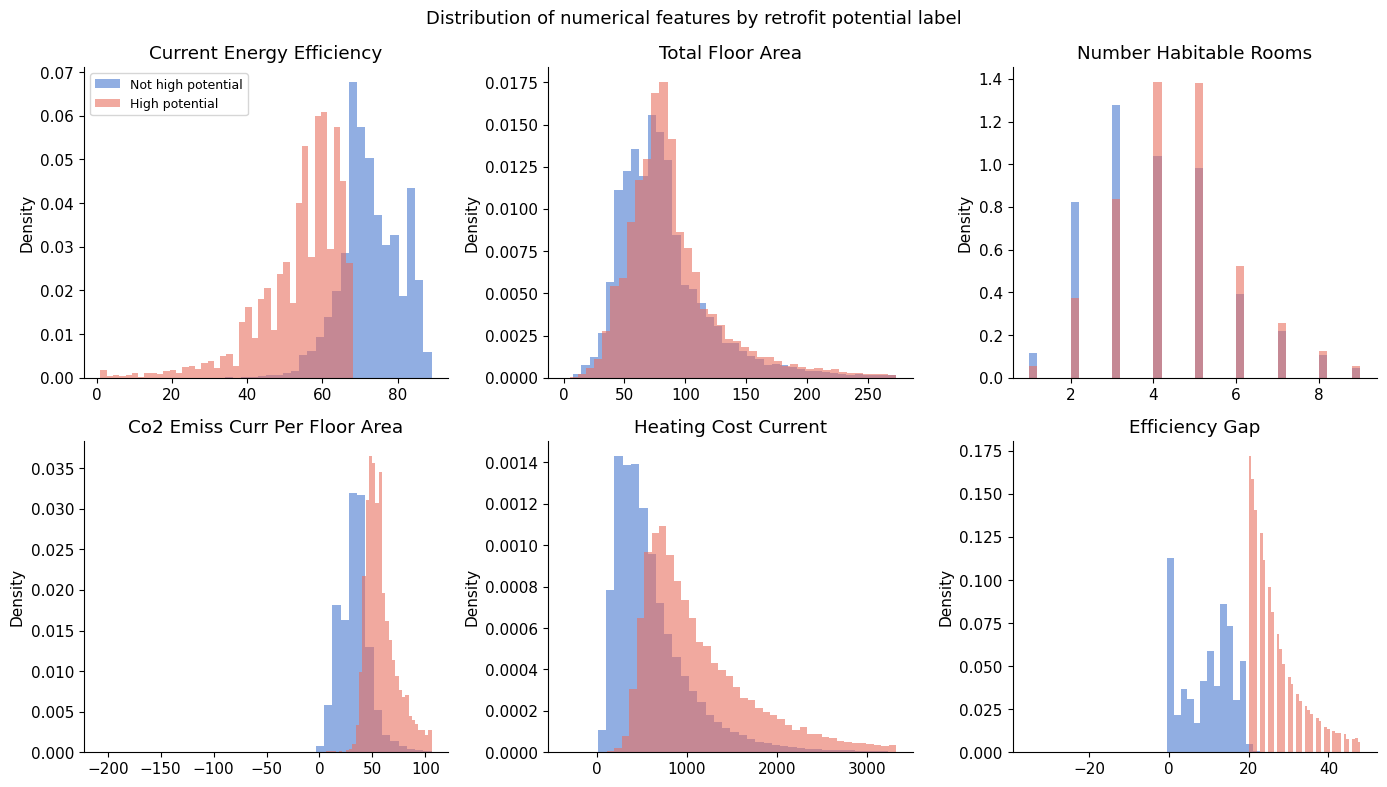

In [6]:
num_cols = [
    'CURRENT_ENERGY_EFFICIENCY', 'TOTAL_FLOOR_AREA',
    'NUMBER_HABITABLE_ROOMS', 'CO2_EMISS_CURR_PER_FLOOR_AREA',
    'HEATING_COST_CURRENT', 'EFFICIENCY_GAP'
]
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Cap TOTAL_FLOOR_AREA at 99th percentile for readability
    data = df[col].dropna()
    cap = data.quantile(0.99)
    data = data[data <= cap]
    
    ax.hist(data[df.loc[data.index, 'RETROFIT_POTENTIAL'] == 0], bins=40,
            alpha=0.6, color='steelblue', label='Not high potential', density=True)
    ax.hist(data[df.loc[data.index, 'RETROFIT_POTENTIAL'] == 1], bins=40,
            alpha=0.6, color='coral', label='High potential', density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

# Hide unused panels
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of numerical features by retrofit potential label', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_numerical_distributions.png', bbox_inches='tight')
plt.show()

## 5. Correlation heatmap (numerical features)

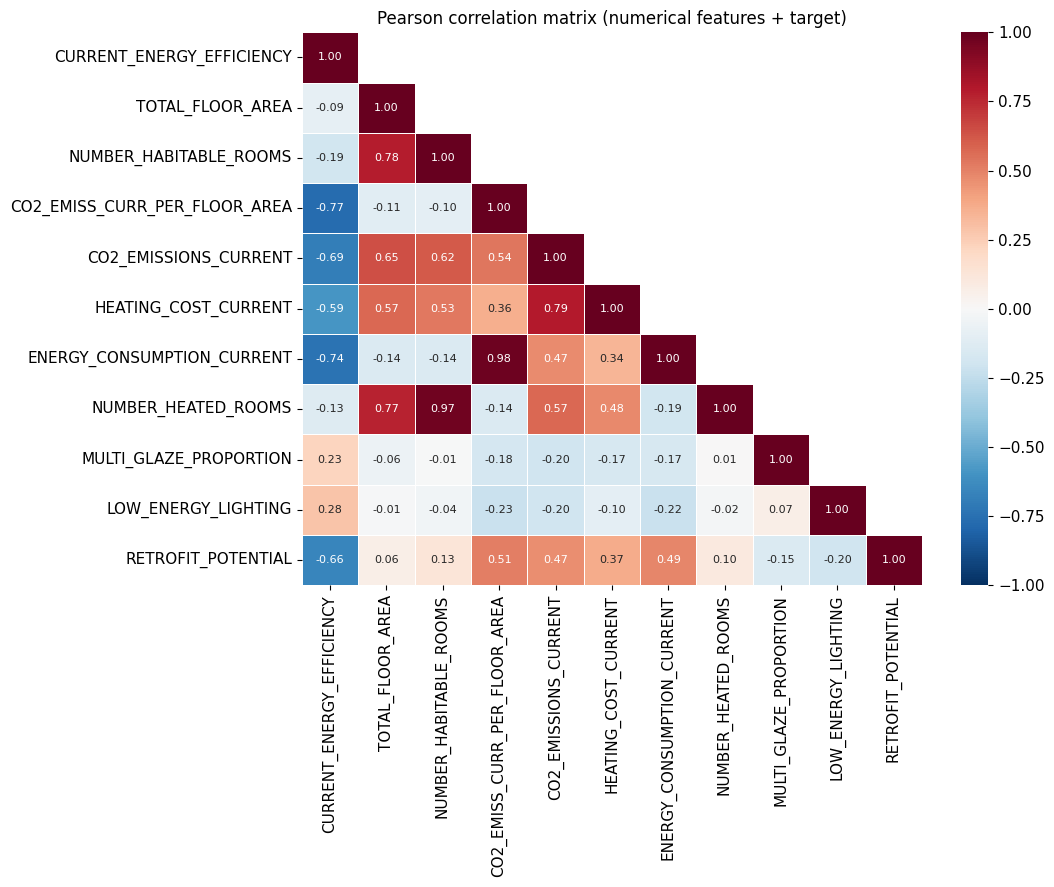

In [7]:
corr_cols = [
    'CURRENT_ENERGY_EFFICIENCY', 'TOTAL_FLOOR_AREA',
    'NUMBER_HABITABLE_ROOMS', 'CO2_EMISS_CURR_PER_FLOOR_AREA',
    'CO2_EMISSIONS_CURRENT', 'HEATING_COST_CURRENT',
    'ENERGY_CONSUMPTION_CURRENT', 'NUMBER_HEATED_ROOMS',
    'MULTI_GLAZE_PROPORTION', 'LOW_ENERGY_LIGHTING',
    'RETROFIT_POTENTIAL'
]
corr_cols = [c for c in corr_cols if c in df.columns]

# Short, readable labels for the plot only (raw column names stay in df).
# The raw names rotated 90deg at 8pt annotation size were unreadable once
# the report shrinks this to column/page width, not just at native size.
plot_labels = {
    'CURRENT_ENERGY_EFFICIENCY': 'Current efficiency',
    'TOTAL_FLOOR_AREA': 'Floor area',
    'NUMBER_HABITABLE_ROOMS': 'Habitable rooms',
    'CO2_EMISS_CURR_PER_FLOOR_AREA': 'CO2 / floor area',
    'CO2_EMISSIONS_CURRENT': 'CO2 emissions',
    'HEATING_COST_CURRENT': 'Heating cost',
    'ENERGY_CONSUMPTION_CURRENT': 'Energy consumption',
    'NUMBER_HEATED_ROOMS': 'Heated rooms',
    'MULTI_GLAZE_PROPORTION': 'Multi-glaze %',
    'LOW_ENERGY_LIGHTING': 'Low-energy lighting %',
    'RETROFIT_POTENTIAL': 'Retrofit potential',
}

corr = df[corr_cols].corr()
corr = corr.rename(index=plot_labels, columns=plot_labels)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson correlation matrix (numerical features + target)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_correlation_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()


## 6. Energy rating distribution by property type

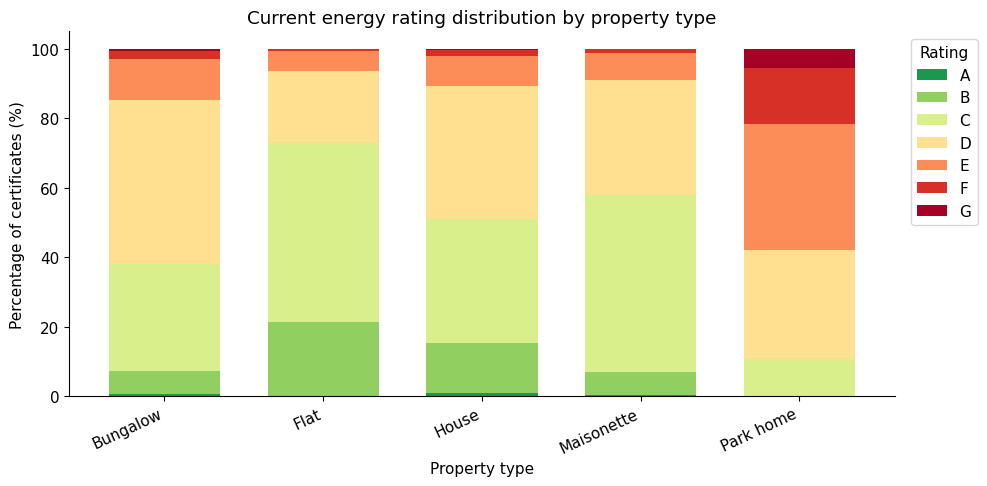

In [8]:
rating_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
prop_types = df['PROPERTY_TYPE'].dropna().unique()

cross = (
    df.groupby(['PROPERTY_TYPE', 'CURRENT_ENERGY_RATING'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[r for r in rating_order if r in df['CURRENT_ENERGY_RATING'].unique()])
)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
# Green (best) to red (worst) across however many rating bands are present
colors = plt.cm.RdYlGn(np.linspace(0.85, 0.1, len(cross_pct.columns)))
cross_pct.plot(kind='bar', stacked=True, ax=ax,
               color=colors, width=0.7)
ax.set_xlabel('Property type')
ax.set_ylabel('Percentage of certificates (%)')
ax.set_title('Current energy rating distribution by property type')
ax.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_rating_by_property_type.png', bbox_inches='tight')
plt.show()

## 7. Retrofit potential rate by construction age band

In [ ]:
import re

# CONSTRUCTION_AGE_BAND is messy: the 12 standard 'England and Wales: <range>' bands are
# mixed with bare 4-digit build years (e.g. 2021, 1750). Plotting the raw column gives ~60
# overlapping bars. Bucket the stray years into their band and plot the 12 in chronological
# order so the trend is readable.
BANDS = [
    ('before 1900', -1, 1899), ('1900-1929', 1900, 1929), ('1930-1949', 1930, 1949),
    ('1950-1966', 1950, 1966), ('1967-1975', 1967, 1975), ('1976-1982', 1976, 1982),
    ('1983-1990', 1983, 1990), ('1991-1995', 1991, 1995), ('1996-2002', 1996, 2002),
    ('2003-2006', 2003, 2006), ('2007-2011', 2007, 2011), ('2012 onwards', 2012, 3000),
]
band_order = [b[0] for b in BANDS]

def to_band(v):
    if pd.isna(v):
        return np.nan
    s = str(v).replace('England and Wales:', '').strip()
    for name, lo, hi in BANDS:
        if s == name:
            return name
    m = re.fullmatch(r'(\d{4})(\.0)?', s)
    if m:
        y = int(m.group(1))
        for name, lo, hi in BANDS:
            if lo <= y <= hi:
                return name
    return np.nan

if 'CONSTRUCTION_AGE_BAND' in df.columns:
    band = df['CONSTRUCTION_AGE_BAND'].map(to_band)
    age_rate = (df.assign(_band=band)
                  .dropna(subset=['_band'])
                  .groupby('_band')['RETROFIT_POTENTIAL'].mean()
                  .reindex(band_order).dropna())

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(age_rate.index[::-1], age_rate.values[::-1] * 100, color='steelblue')
    ax.set_xlabel('High retrofit potential rate (%)')
    ax.set_title('Retrofit potential rate by construction age band')
    ax.axvline(df['RETROFIT_POTENTIAL'].mean() * 100, color='red', linestyle='--',
               label=f'Overall mean ({df["RETROFIT_POTENTIAL"].mean():.1%})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/06_retrofit_rate_by_age.png', bbox_inches='tight')
    plt.show()


## 7b. Data quality: impossible negative values

Several physical-quantity fields (energy consumption, CO2 emissions, and cost) contain negative values, which are impossible and indicate sentinel or data-entry errors in the source register. These are quantified below and removed during feature engineering (notebook 02).

In [ ]:
non_negative_cols = [
    'CURRENT_ENERGY_EFFICIENCY', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS',
    'NUMBER_HEATED_ROOMS', 'CO2_EMISS_CURR_PER_FLOOR_AREA', 'CO2_EMISSIONS_CURRENT',
    'ENERGY_CONSUMPTION_CURRENT', 'HEATING_COST_CURRENT', 'HOT_WATER_COST_CURRENT',
    'LIGHTING_COST_CURRENT', 'EXTENSION_COUNT', 'FIXED_LIGHTING_OUTLETS_COUNT',
    'MULTI_GLAZE_PROPORTION', 'LOW_ENERGY_LIGHTING',
]
present = [c for c in non_negative_cols if c in df.columns]
neg_counts = {c: int((df[c] < 0).sum()) for c in present if (df[c] < 0).any()}
n_bad = int((df[present] < 0).any(axis=1).sum())
print(f'Rows with any negative physical value: {n_bad:,} ({n_bad/len(df)*100:.3f}%)')
for c, n in sorted(neg_counts.items(), key=lambda kv: -kv[1]):
    print(f'  {c}: {n} negative, min = {df[c].min()}')

## 8. Summary statistics

In [10]:
print('=== SUMMARY STATISTICS (train sample) ===')
print(f'Total records:          {len(df):,}')
print(f'High retrofit potential: {df["RETROFIT_POTENTIAL"].sum():,} ({df["RETROFIT_POTENTIAL"].mean():.1%})')
print(f'Columns:                {df.shape[1]}')
print(f'Missing values (any col):{df.isnull().any(axis=1).sum():,} rows ({df.isnull().any(axis=1).mean():.1%})')
print()
print('Property type counts:')
print(df['PROPERTY_TYPE'].value_counts())
print()
print('Current energy rating counts:')
print(df['CURRENT_ENERGY_RATING'].value_counts().sort_index())

=== SUMMARY STATISTICS (train sample) ===
Total records:          200,000
High retrofit potential: 43,386 (21.7%)
Columns:                41
Missing values (any col):200,000 rows (100.0%)

Property type counts:
PROPERTY_TYPE
House         118818
Flat           61299
Bungalow       14785
Maisonette      4903
Park home        195
Name: count, dtype: int64

Current energy rating counts:
CURRENT_ENERGY_RATING
A     1287
B    31386
C    81326
D    66545
E    16025
F     2626
G      805
Name: count, dtype: int64


## EDA Conclusions

1. **Class imbalance:** 21.7% positive in training data. A model that predicts all-zero would achieve 78.3% accuracy — accuracy is not the right metric. We will use F1-macro and ROC-AUC throughout.
2. **Temporal shift:** The test set (2025-2026) has only 10.8% positive, meaning the model must generalise across a changing distribution. This is realistic for policy deployment.
3. **Floor area outliers:** TOTAL_FLOOR_AREA has extreme values (likely data entry errors). Median imputation and capping at the 99th percentile are justified.
4. **Missing values:** Several description-derived fields have non-trivial missingness. Median imputation for numerics and 'unknown' category for categoricals are appropriate.
5. **Construction age:** Pre-1966 properties have the highest retrofit potential rate, which aligns with policy knowledge (poorly insulated solid-wall properties).
6. **Current efficiency score:** Strongly separates the classes — a key feature for all models.

**Next step:** `02_Feature_Engineering.ipynb` — build the sklearn preprocessing pipeline.